In [1]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t
import itertools as it
from scipy.stats import gaussian_kde
import seaborn as sns


prefix_list = ['UQ_20231113', 'UQ_20240312_test20241025']
N_list = [4000, 128]
BLOCK_LIST = [200, 16]
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'HR', 'NEE'] # , 'TOTSOMC']

In [2]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collection_sim = {}

for N, BLOCK, prefix in zip(N_list, BLOCK_LIST, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # revert the signs of NEE & HR to be compatible with Paul's data
    # collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
    # TEMPORARY
    collect[:, -2:, :, :] = - collect[:, -2:, :, :]

    collection_sim[prefix] = collect

In [3]:
collection_sim[prefix].shape, collection_sim.keys()

((128, 14, 2, 4), dict_keys(['UQ_20231113', 'UQ_20240312_test20241025']))

In [4]:
# Get the parameters
def get_params(prefix, parname, N, ensemble_members = None):
#    prefix = 'UQ_20240311'
#    parname = 'kmin_nuptake'
#    N = 2000
    uqroot = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC')
    if ensemble_members is None:
        ensemble_members = range(1, N+1)
    N = len(ensemble_members)
    count = 0
    for b in ensemble_members:
        hr = xr.open_dataset( os.path.join(uqroot, f'g{b:05d}', f'clm_params_{b:05d}.nc') )
        parvals = hr[parname].values
        hr.close()
        if count == 0:
            if parvals.shape == ():
                parcollect = np.full([N, 1], np.nan)
            else:
                parcollect = np.full([N, len(parvals)], np.nan)
        if parvals.shape == ():
            parcollect[count, 0] = parvals
        else:
            parcollect[count, :] = parvals.reshape(-1)
        count = count + 1
    return parcollect

In [5]:
collection_obs = uq_get_obs(VAR_LIST)
collection_obs

mean    mean_std      slope  slope_std
Variable                CO2                                                
AGBiomass_Spruce        amb   1017.021727  144.948741 -20.812852  14.330421
                        elev  1056.702388  132.904337 -10.641595  14.008872
AGBiomass_Tamarack      amb    279.636238   48.131644   0.956728   5.350410
                        elev   254.377602   33.429096   2.845130   3.506717
AGBiomass_Shrub         amb    270.340560  144.068094  14.201267  15.223928
                        elev   302.026760  127.044918  11.058754  13.301223
AGNPPtoBiomass_Spruce   amb      0.085801    0.038827  -0.006844   0.003567
                        elev     0.106010    0.023628   0.002045   0.002475
AGNPPtoBiomass_Tamarack amb      0.139133    0.042208   0.002246   0.004632
                        elev     0.158908    0.085972   0.003056   0.009326
AGNPPtoBiomass_Shrub    amb      0.339493    0.124717   0.005989   0.013726
                        elev     0.386659    0.105875   0.009616   0.011041
AGNPP_Spruce            amb     90.367160   70.327725  -7.412613   7.372231
                        elev   108.182080   36.850668  -6.237117   3.351306
AGNPP_Tamarack          amb     41.946960   18.074609   0.357145   2.009258
                        elev    27.670120   19.440455   1.706969   2.033783
AGNPP_Shrub             amb     83.706280   39.186727   4.888405   4.000128
                        elev   111.648920   45.271973   7.450332   4.166588
NPP_moss                amb     93.539700   54.460756 -10.250541   3.237914
                        elev    64.657760   42.817475  -6.800788   3.995419
BGNPP_TreeShrub         amb     75.163750   36.653675   6.770230   2.220529
                        elev    79.211250   42.878170  10.162000   2.957010
BGtoAG_TreeShrub        amb      0.458657    0.218226   0.021313   0.023084
                        elev     0.321365    0.162943   0.037774   0.011597
HR                      amb   -429.644529   91.562006 -20.084135   4.317464
                        elev  -460.730872   84.337116 -22.430646   4.537966
NEE                     amb   -174.324416  162.204511 -29.397569  10.000740
                        elev  -210.644919  127.722575 -26.863250  10.121259

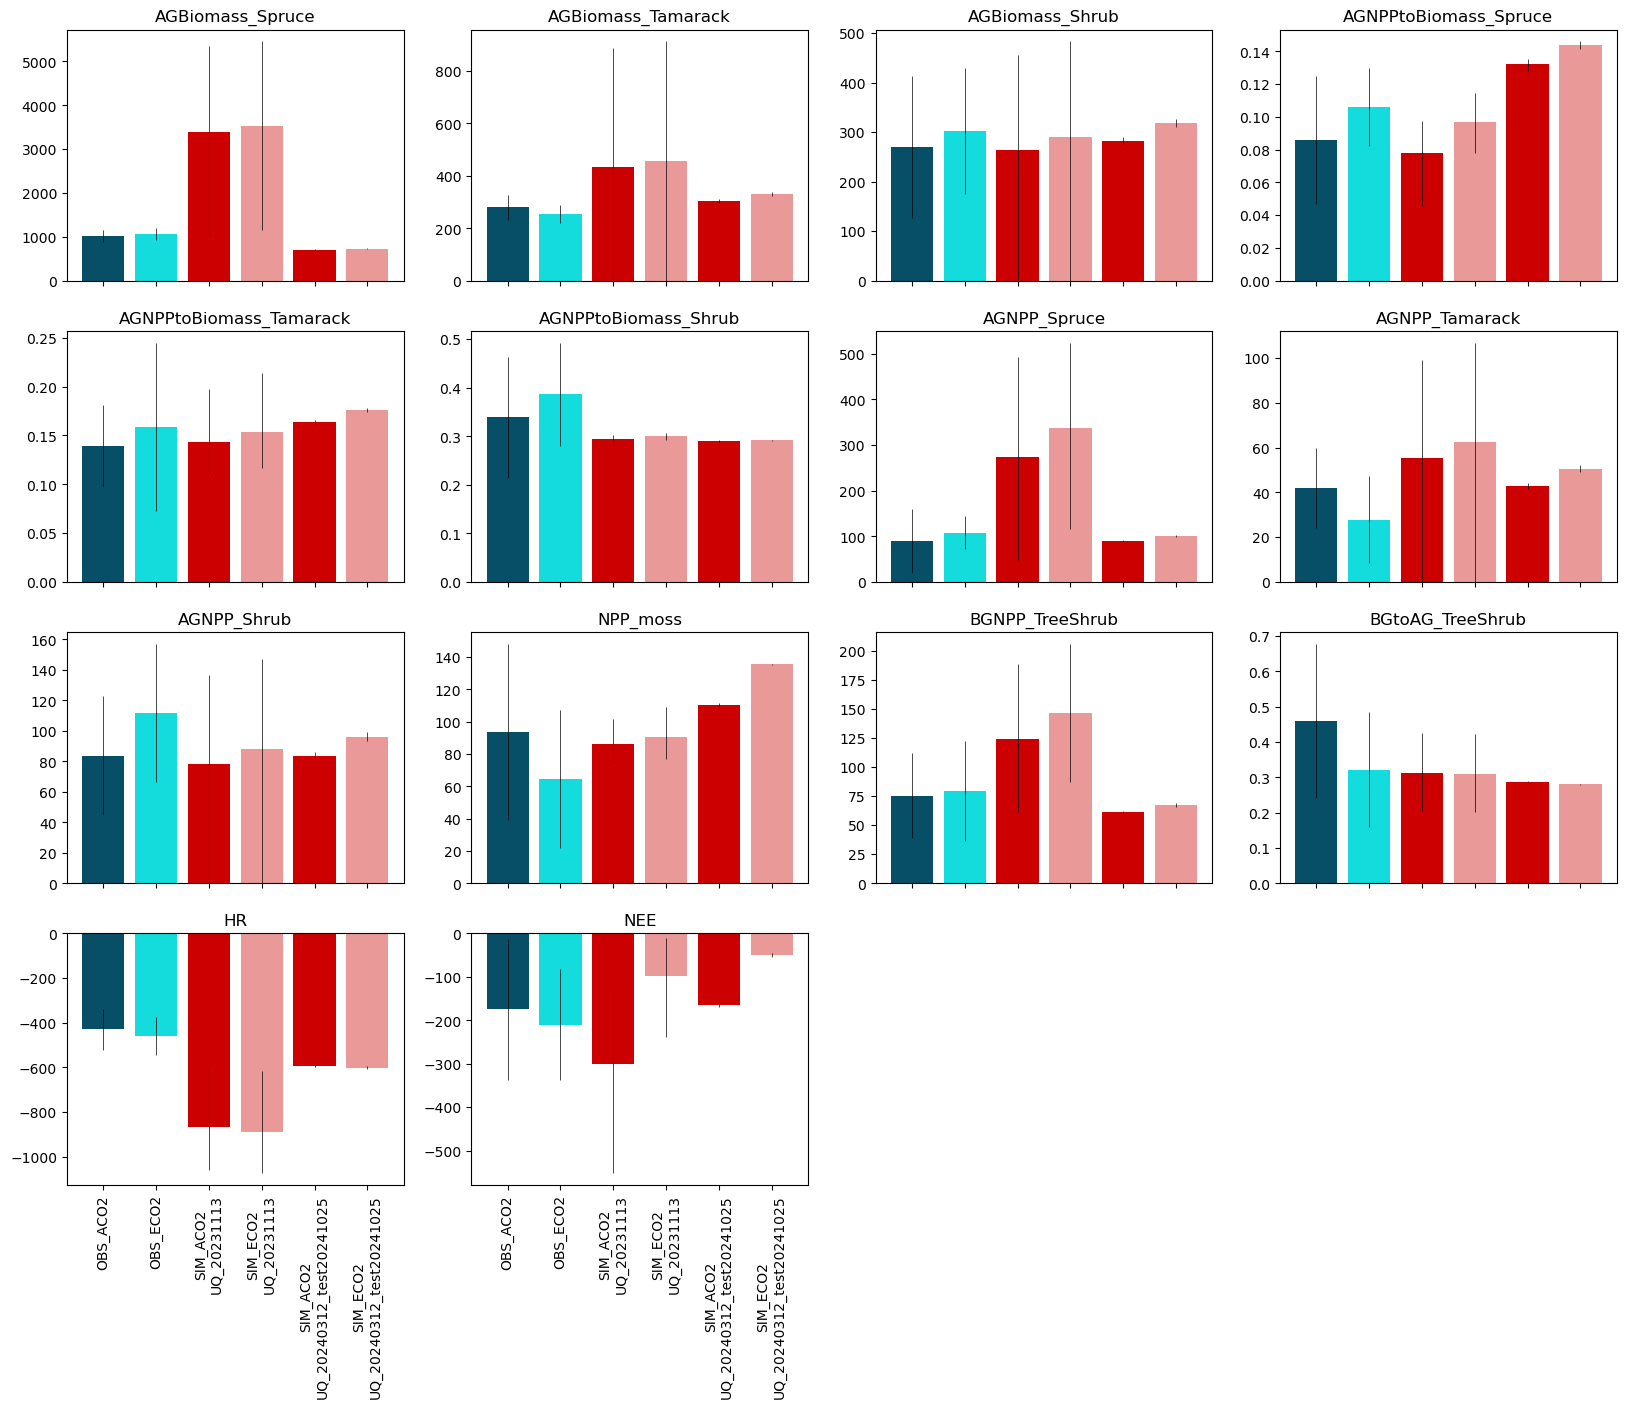

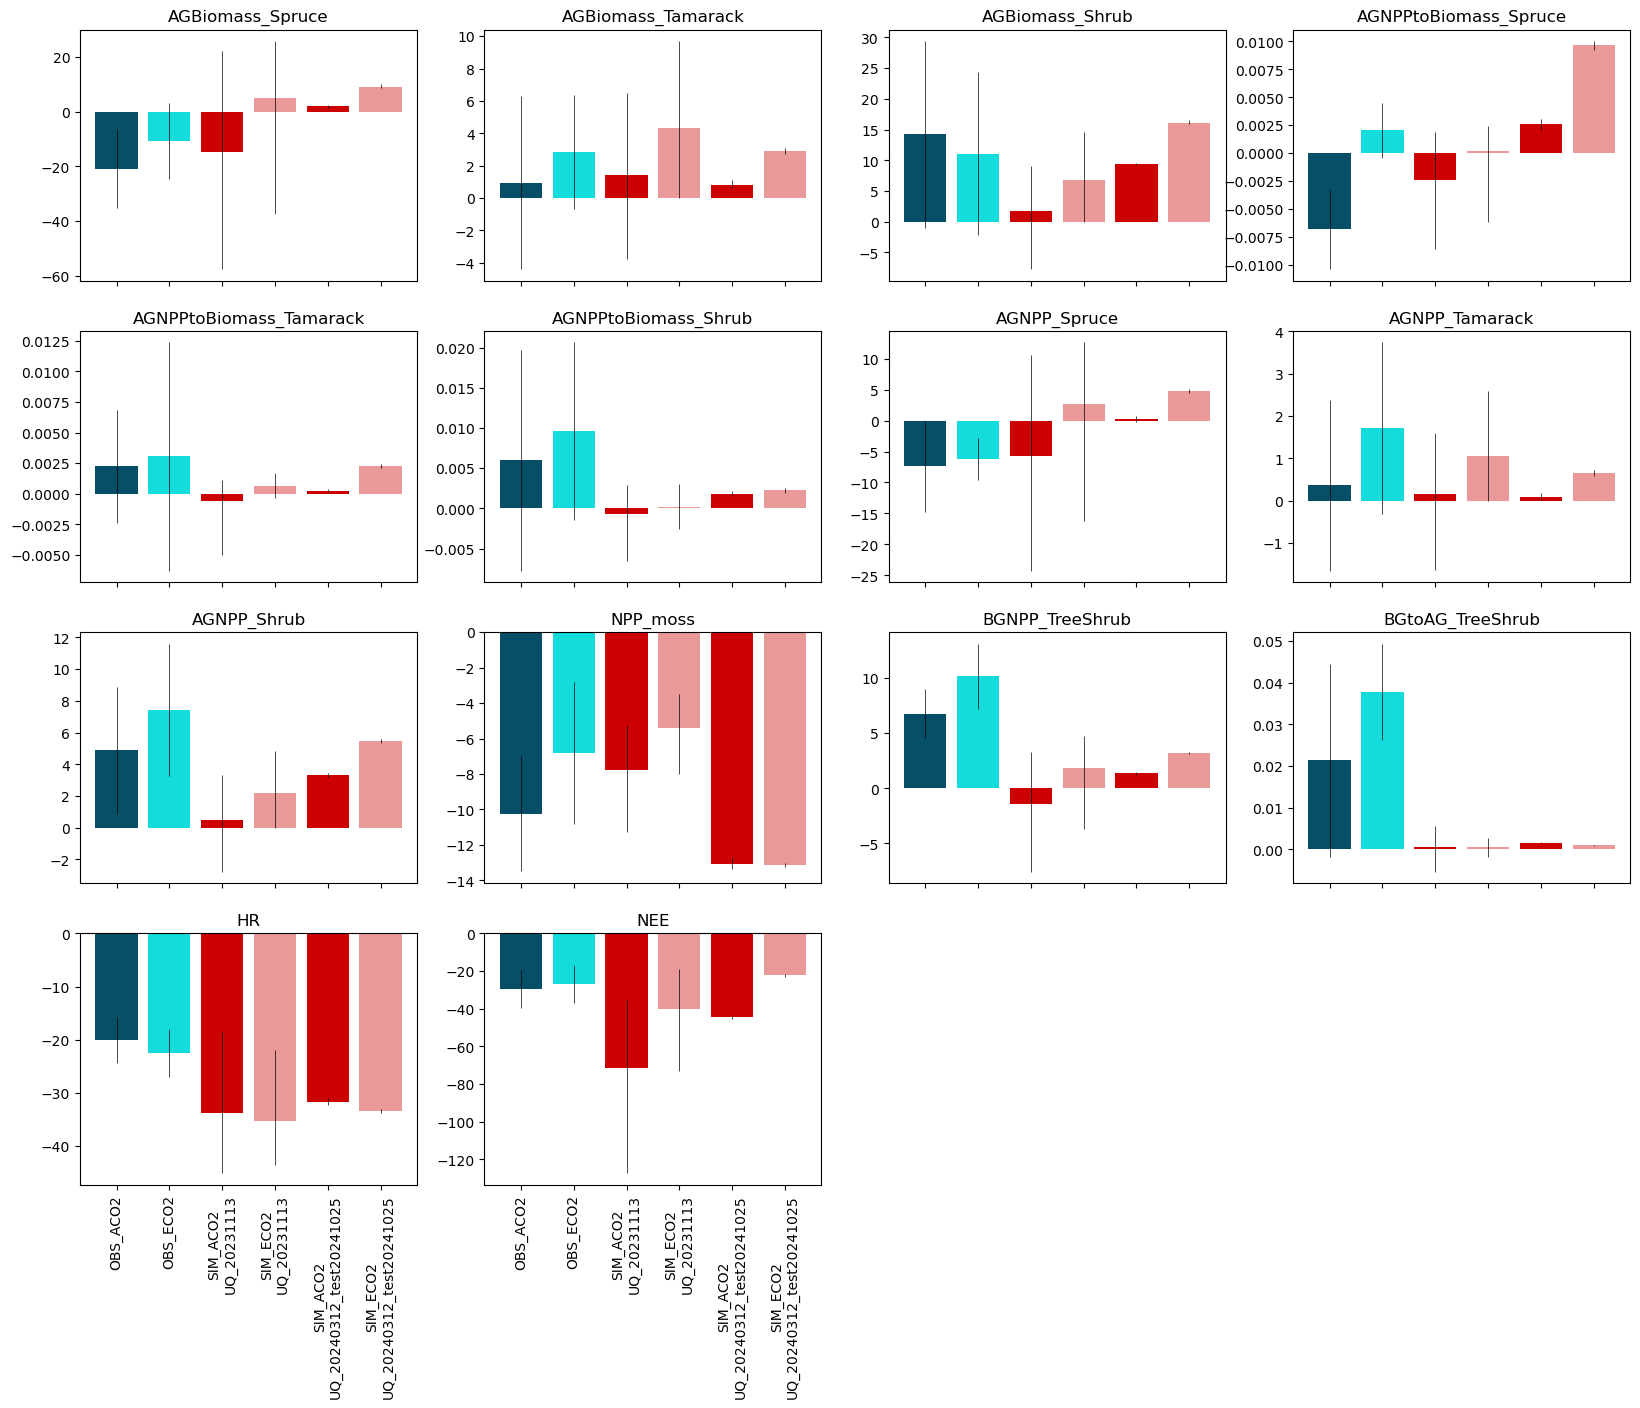

In [6]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 4, figsize = (20, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]

            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
                   color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                        collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0)
                temp_q5 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 5, axis = 0)
                temp_q95 = np.nanpercentile(collection_sim[prefix][:, i, :, k], 95, axis = 0)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, [temp - temp_q5, temp_q95 - temp], 
                            ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])

        plt.setp(ax.get_xticklabels(), rotation = 90)

In [14]:
prefix_of_interest = 'UQ_20240312_test20241025'

VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub', 'NPP_moss',
               'BGNPP_TreeShrub','HR','NEE']
ind_list = []
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

# the 2 is ACO2 and ECO2
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)
sim_mean = collection_sim[prefix_of_interest][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
sim_slope = collection_sim[prefix_of_interest][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

rmse_mean = np.sqrt(np.mean(np.power((sim_mean - obs_mean) / \
                                     (np.abs(obs_mean)) * 2, 2),
                            axis = 1))
rmse_slope = np.sqrt(np.mean(np.power((sim_slope - obs_slope) / \
                                      (np.abs(obs_slope)) * 2, 2),
                             axis = 1))
rmse_tot = np.sqrt((rmse_mean**2 + rmse_slope**2)/2)

n_best_ind = 10
best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]
print(f'top {n_best_ind} best runs = ', best_inds + 1)
print(f'top {n_best_ind} best rmses = ', rmse_tot[best_inds])
best_ind = np.nanargmin(rmse_tot)
print('best run = ', best_ind + 1)

top 10 best runs =  [ 27  39  22 127  91  74 113  90  43  83]
top 10 best rmses =  [1.2276085  1.23050614 1.22947061 1.22677935 1.22568709 1.22539398
 1.22196803 1.22160282 1.23257183 1.23289869]
best run =  90


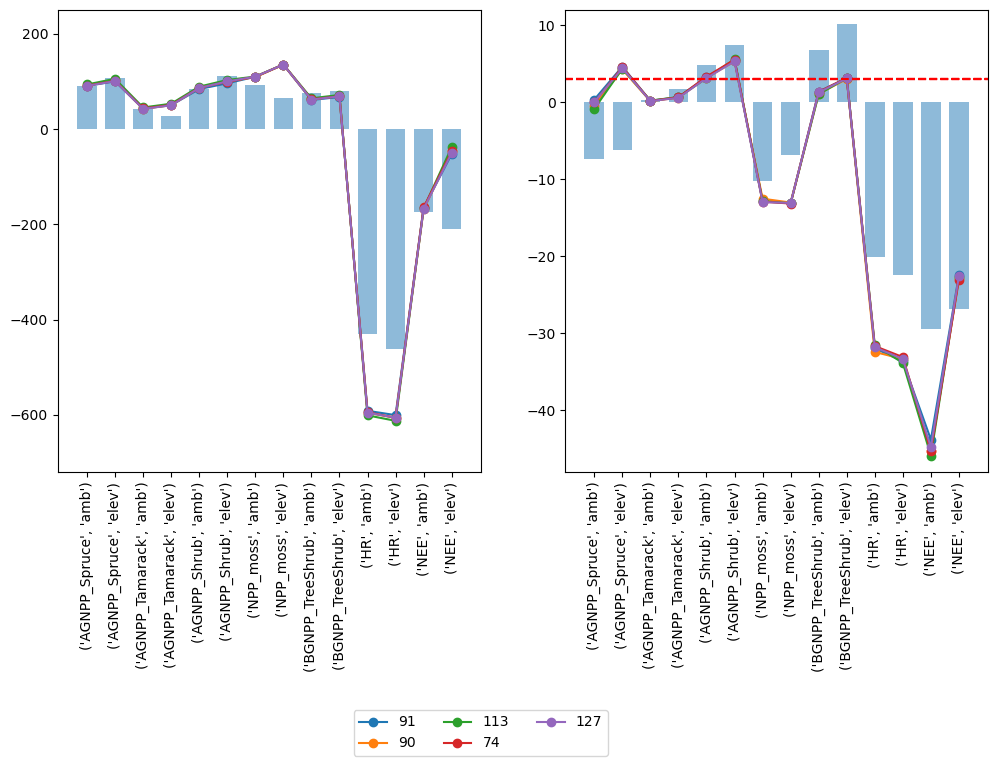

In [9]:
#fig, ax = plt.subplots(figsize = (12, 12))
#ax.plot(rmse_mean, rmse_slope, 'o')
#ax.set_xlim([0,2])
#ax.set_ylim([0,2])

fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharex = True)
for i, bi in enumerate(best_inds):
    compare = pd.DataFrame({
        'obs_mean': obs_mean[0, :], 
        'sim_mean': sim_mean[bi, :],
        'obs_slope': obs_slope[0, :],
        'sim_slope': sim_slope[bi, :]
    }, index = pd.MultiIndex.from_tuples([(var,co2) for var in VAR_SUBSET for co2 in ['amb', 'elev']]))

    # print(compare)

    ax = axes[0]
    if i == 0:
        ax.bar(np.arange(compare.shape[0]), compare['obs_mean'], width = 0.7, alpha = 0.5)
    ax.plot(np.arange(compare.shape[0]), compare['sim_mean'], '-o', label = bi+1)
    ax.set_xticks(np.arange(compare.shape[0]))
    ax.set_xticklabels(compare.index, rotation = 90)
    ax.set_ylim([-720, 250])

    ax = axes[1]
    if i == 0:
        ax.bar(np.arange(compare.shape[0]), compare['obs_slope'], width = 0.7, alpha = 0.5)
    ax.plot(np.arange(compare.shape[0]), compare['sim_slope'], '-o', label = bi+1)
    ax.set_xticks(np.arange(compare.shape[0]))
    ax.set_xticklabels(compare.index, rotation = 90)
    ax.set_ylim([-48, 12])
    ax.axhline(3, ls = '--', color = 'r')
    # ax.set_ylim([0,5])
ax.legend(ncol = min(7,int(np.ceil(n_best_ind / 2))), bbox_to_anchor = (-0.2, -0.5), 
          loc = 'upper center')

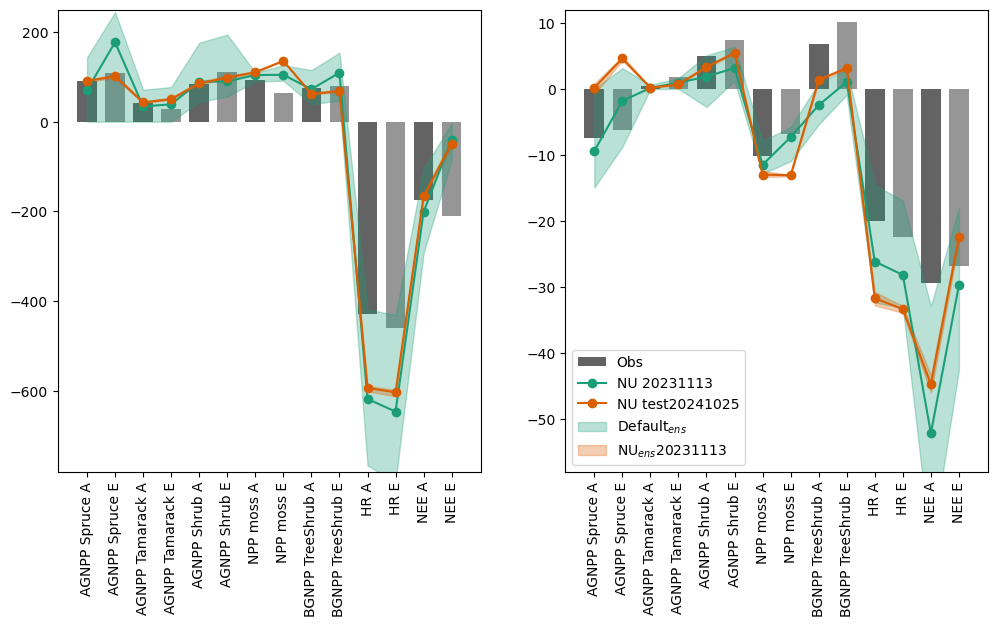

In [15]:
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
#VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub','NPP_moss',
#               'BGNPP_TreeShrub','HR','NEE']
xticklabels = [var.replace('_',' ')+f' {co2}' for var in VAR_SUBSET for co2 in ['A', 'E']]
ind_list = [] # the index to VAR_SUBSET that we are interested in
for i,var in enumerate(VAR_LIST):
    if var in VAR_SUBSET:
        ind_list.append(i)
ind_list = np.array(ind_list)

#
n_best_ind = 40
obs_mean = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 0].reshape(1,-1)
obs_slope = collection_obs.values.reshape(-1, 2, 4)[ind_list, :, 2].reshape(1,-1)

#
fig, axes = plt.subplots(1, 2, figsize = (12, 6), sharex = True)
ax = axes[0]
h1 = ax.bar(np.arange(compare.shape[0]), compare['obs_mean'], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
ax = axes[1]
h1 = ax.bar(np.arange(compare.shape[0]), compare['obs_slope'], width = 0.7,
            color = ['#636363', '#969696'] * len(VAR_SUBSET))
clist = ['#1b9e77', '#d95f02', '#e7298a']
h2 = [None] * len(prefix_list)
h3 = [None] * len(prefix_list)
for p, prefix in enumerate(prefix_list):

    # the 2 is ACO2 and ECO2
    sim_mean = collection_sim[prefix][:, ind_list, :][:,:,:,0].reshape(-1, 2*len(ind_list))
    sim_slope = collection_sim[prefix][:, ind_list, :][:,:,:,2].reshape(-1, 2*len(ind_list))

    # find the best runs
    rmse_mean = np.sqrt(np.mean(np.power((sim_mean - obs_mean) / \
                                        (np.abs(obs_mean)) * 2, 2),
                                axis = 1))
    rmse_slope = np.sqrt(np.mean(np.power((sim_slope - obs_slope) / \
                                        (np.abs(obs_slope)) * 2, 2),
                                axis = 1))
    rmse_tot = np.sqrt((rmse_mean**2 + rmse_slope**2)/2)
    if n_best_ind >= len(rmse_tot):
        best_inds = range(n_best_ind)
    else:
        best_inds = np.argpartition(rmse_tot, n_best_ind)[:n_best_ind]

    sim_mean_bi = sim_mean[best_inds, :]
    sim_slope_bi = sim_slope[best_inds, :]

    ax = axes[0]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_mean[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_mean[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_mean[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_mean[2851, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_mean_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_mean_bi.shape[1]), 
                            np.min(sim_mean_bi, axis = 0),
                            np.max(sim_mean_bi, axis = 0), color = clist[p], alpha = 0.3)
    ax.set_xticks(np.arange(sim_mean_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-780, 250])

    ax = axes[1]
    if prefix == 'UQ_20240311_2':
        h2[p], = ax.plot(sim_slope[2461, :], '-o', color = clist[p])
    elif prefix == 'UQ_20231113':
        h2[p], = ax.plot(sim_slope[681, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241012':
        h2[p], = ax.plot(sim_slope[2, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241013':
        h2[p], = ax.plot(sim_slope[900, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241017':
        h2[p], = ax.plot(sim_slope[2851, :], '-o', color = clist[p])
    elif prefix == 'UQ_20240312_test20241025':
        h2[p], = ax.plot(sim_slope[25, :], '-o', color = clist[p])
    else:
        h2[p], = ax.plot(sim_slope_bi.mean(axis = 0), '-o', color = clist[p])
    h3[p] = ax.fill_between(np.arange(sim_slope_bi.shape[1]), 
                            np.min(sim_slope_bi, axis = 0),
                            np.max(sim_slope_bi, axis = 0), color = clist[p], alpha = 0.3)
    ax.set_xticks(np.arange(sim_slope_bi.shape[1]))
    ax.set_xticklabels(xticklabels, rotation = 90)
    ax.set_ylim([-58, 12])
ax.legend([h1] + h2 + h3, ['Obs'] + ['NU ' + p.split('_')[-1] for p in prefix_list] + \
          ['Default$_{ens}$'] + ['NU$_{ens}$' + p.split('_')[-1] for p in prefix_list],
          loc = 'lower left')

KeyError: 'UQ_20240312_test20241013'

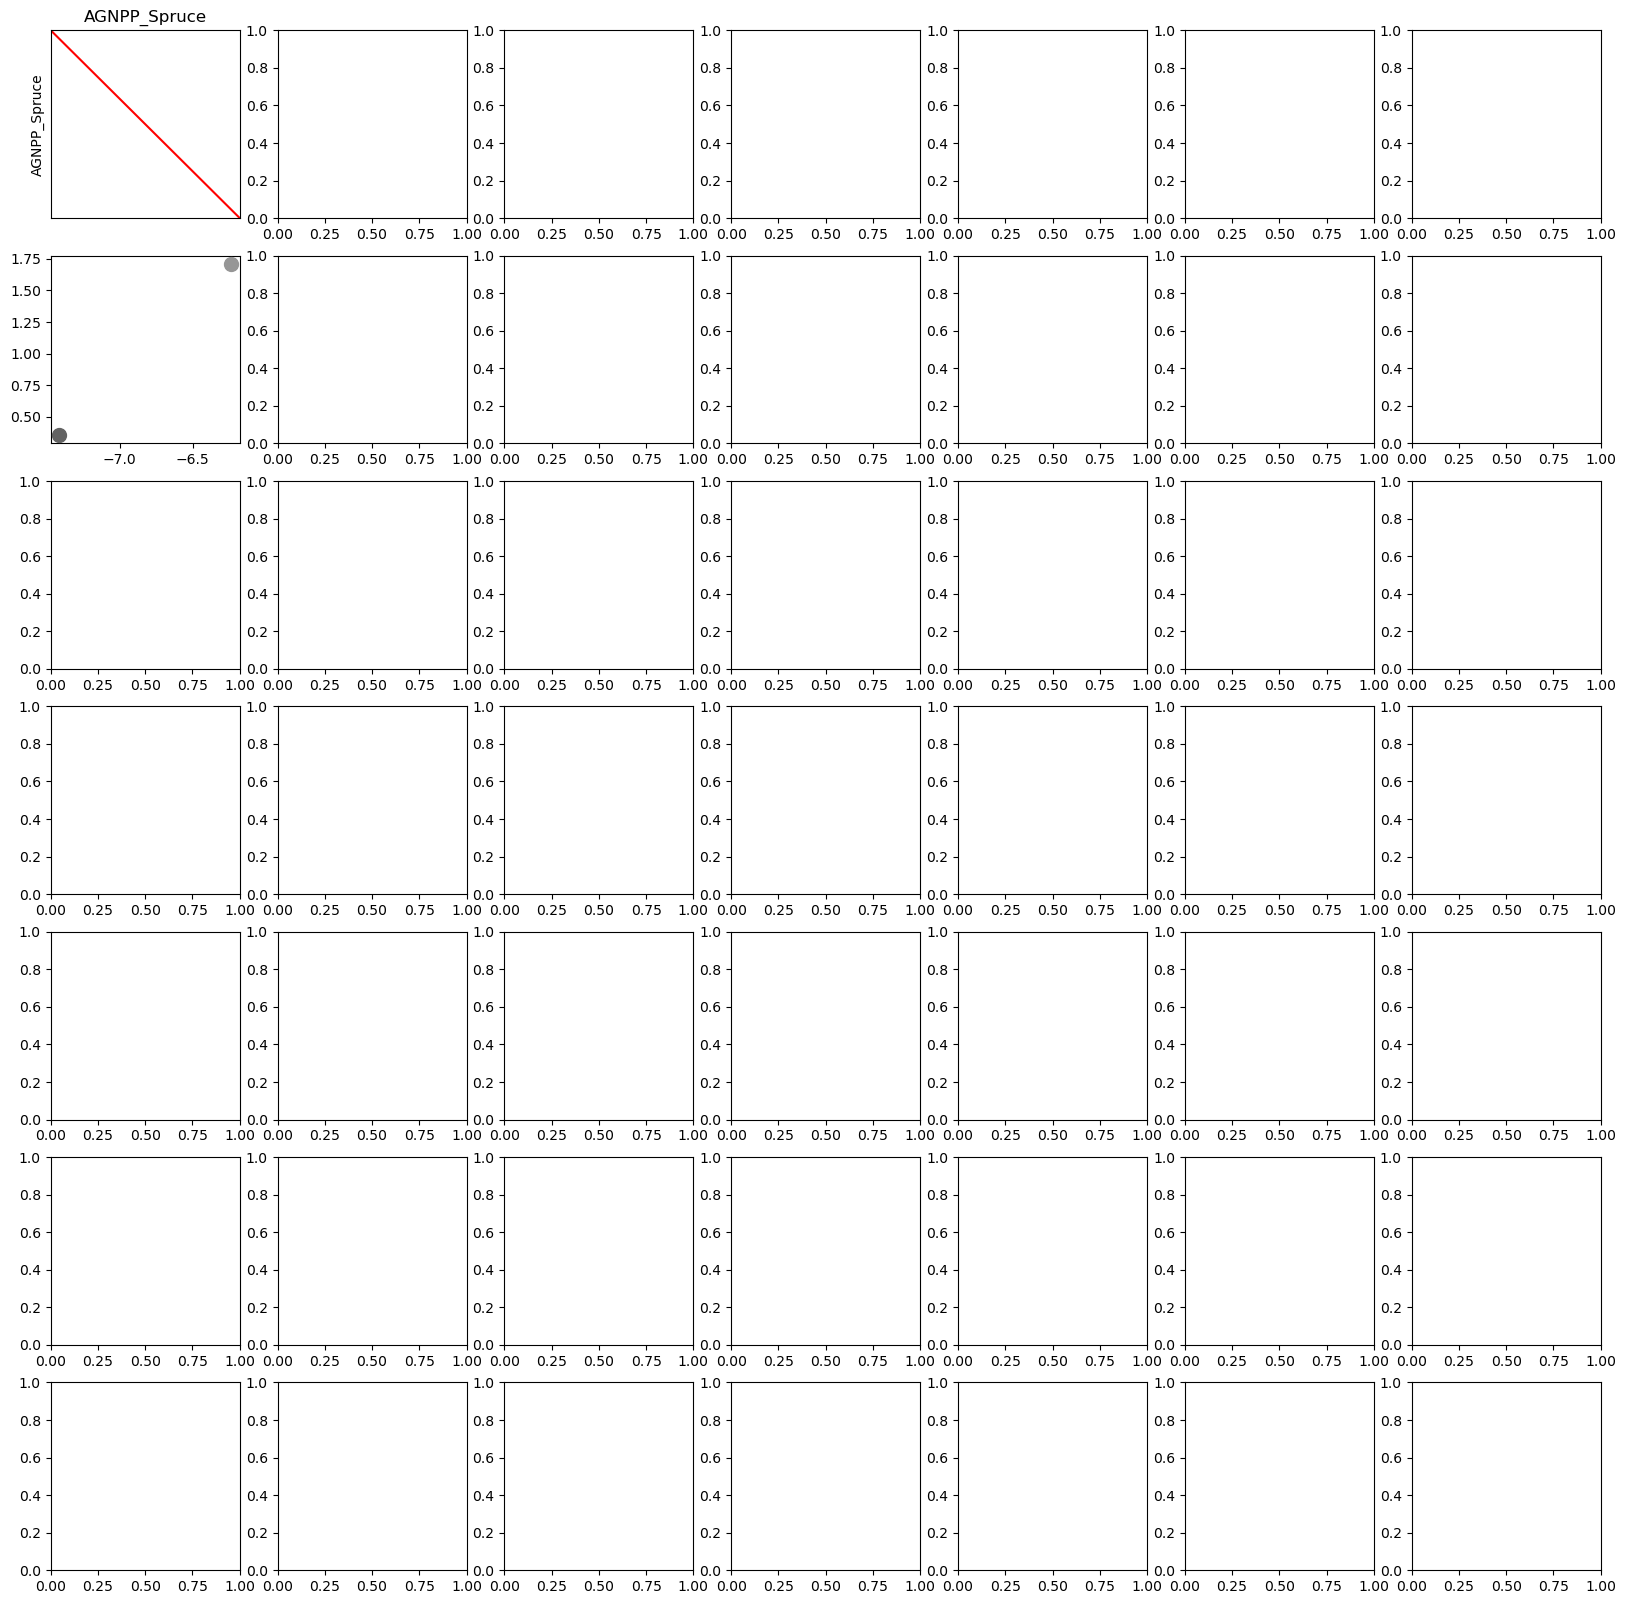

In [11]:
# Across the sensitivity parameters, check relationship between HR mean and shrub slope
# Make a nicer graph that overlays the top 10 best runs of each prefix_list
VAR_SUBSET =  ['AGNPP_Spruce','AGNPP_Tamarack','AGNPP_Shrub','NPP_moss',
               'BGNPP_TreeShrub','HR','NEE']
VAR_lim = {
    'AGNPP_Spruce': [-40, 20],
    'AGNPP_Tamarack': [-6, 6],
    'AGNPP_Shrub': [-5, 7],
    'NPP_moss': [-18, 4],
    'BGNPP_TreeShrub': [-12, 11],
    'HR': [-60, 0],
    'NEE': [-200,100]
}
VAR_ticks = {
    'AGNPP_Spruce': np.arange(-30, 11, 10), 
    'AGNPP_Tamarack': np.arange(-5, 6, 5), 
    'AGNPP_Shrub': np.arange(-4, 7, 2),
    'NPP_moss': np.arange(-15, 6, 5), 
    'BGNPP_TreeShrub': np.arange(-10, 11, 10),
    'HR': np.arange(-50, 0, 10),
    'NEE': np.arange(-200, 100, 50)
}

mean_ind = 0
slope_ind = 2
fig, axes = plt.subplots(len(VAR_SUBSET), len(VAR_SUBSET), figsize = (20, 20), 
                         sharex = False, sharey = False)
for i, j in it.product(range(len(VAR_SUBSET)), range(len(VAR_SUBSET))):

    for a,var in enumerate(VAR_LIST):
        if var == VAR_SUBSET[i]:
            i_ind = a
        if var == VAR_SUBSET[j]:
            j_ind = a

    # Put ELM-Default on the upper triagle, and ELM-nu on the lower triangle
    if i == j:
        ax = axes[i, j]
        ax.plot([1,-1], [-1, 1], '-r')
        ax.set_xlim([-1,1])
        ax.set_ylim([-1,1])
        ax.set_xticks([])
        ax.set_yticks([])
    else:
        ax = axes[j, i]
        # the 2 is ACO2 and ECO2
        obs_x = collection_obs.values.reshape(-1, 2, 4)[i_ind, :, slope_ind]
        obs_y = collection_obs.values.reshape(-1, 2, 4)[j_ind, :, slope_ind]
        h1, = ax.plot(obs_x[0], obs_y[0], 'o', markersize = 10, color = '#636363',
                    markerfacecolor = '#636363', zorder = 3)
        h2, = ax.plot(obs_x[1], obs_y[1], 'o', markersize = 10, color = '#969696',
                    markerfacecolor = '#969696', zorder = 3)

        if i > j:
            # (1) ELM-Default, upper triangle
            sim_x = collection_sim['UQ_20231113'][:, i_ind, :, slope_ind].reshape(-1, 2)
            sim_y = collection_sim['UQ_20231113'][:, j_ind, :, slope_ind].reshape(-1, 2)
        else:
            # (2) ELM-new, lower triangle, diagonally mirrored
            # plot diagonally mirrored values
            sim_x = collection_sim['UQ_20240312_test20241013'][:, i_ind, :, slope_ind].reshape(-1, 2)
            sim_y = collection_sim['UQ_20240312_test20241013'][:, j_ind, :, slope_ind].reshape(-1, 2)

        xy = np.vstack([sim_x[:,0], sim_y[:,0]])
        z0 = gaussian_kde(xy)(xy)
        h3 = ax.scatter(sim_x[:,0], sim_y[:,0], c = z0, s = 1, cmap = 'Blues', 
                            alpha = 0.5)
        xy = np.vstack([sim_x[:,1], sim_y[:,1]])
        z1 = gaussian_kde(xy)(xy)
        h4 = ax.scatter(sim_x[:,1], sim_y[:,1], c = z0, s = 1, cmap = 'Reds', 
                            alpha = 0.5)

        # Get the axis limit
        ax.set_xlim(VAR_lim[VAR_SUBSET[i]])
        ax.set_ylim(VAR_lim[VAR_SUBSET[j]])
        ax.set_xticks(VAR_ticks[VAR_SUBSET[i]])
        ax.set_yticks(VAR_ticks[VAR_SUBSET[j]])

    if i == 0:
        ax.set_ylabel(VAR_SUBSET[j])
    if j == 0:
        ax.set_title(VAR_SUBSET[i])

for i, j in it.product(range(len(VAR_SUBSET)), range(len(VAR_SUBSET))):
    ax = axes[j,i]
    if j > i:
        ax.invert_xaxis()
        ax.invert_yaxis()
        ax.xaxis.tick_top()
        ax.yaxis.tick_right()
        for spine in ax.spines.values():
            spine.set_color('blue')
        ax.tick_params(axis='x', colors='blue')
        ax.tick_params(axis='y', colors='blue')

ax = axes[0, 0]
h3, = ax.plot(np.nan, np.nan, 'ob')
h4, = ax.plot(np.nan, np.nan, 'or')
ax.legend([h1, h2, h3, h4], ['Obs A', 'Obs E', 'Sim A', 'Sim E'], facecolor='white', framealpha=1, 
          loc = [0.5, 0.5])

## Do more single run checks on parameter relationships

In [ ]:
dummy()

NameError: name 'dummy' is not defined

286


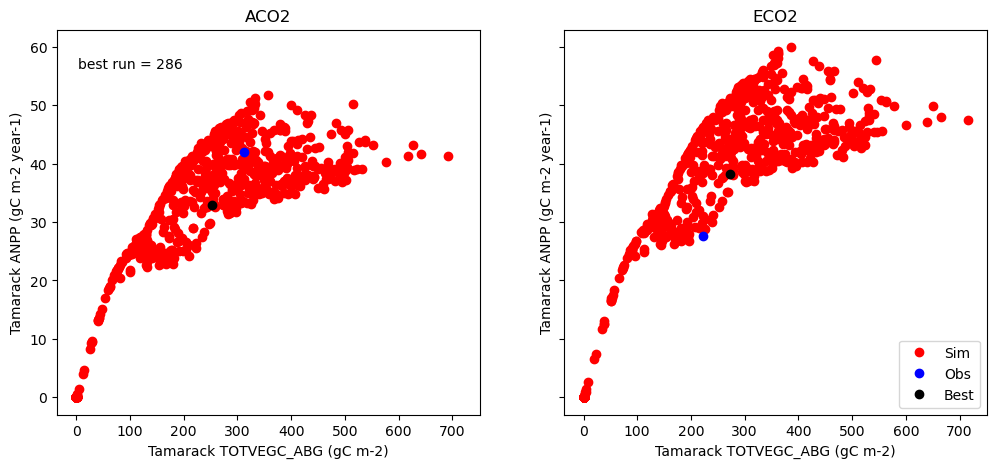

In [ ]:
# Tamarack's AGNPP and TOTVEGC

prefix = 'UQ_20231113_2a'
N = 768

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][:, 4, i, 0]
    mean_anpp_obs = collection_obs.loc[('ANPP_lala',co2), 'mean']
    mean_totvegc_abg = collection_sim[prefix][:, 1, i, 0]
    mean_totvegc_abg_obs = collection_obs.loc[('TOTVEGC_ABG_lala',co2), 'mean']

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg, mean_anpp, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_totvegc_abg_obs,  mean_anpp_obs, 'o', color = 'b', label = 'Obs')

    distance[co2] = \
        np.sqrt( np.power((mean_totvegc_abg - mean_totvegc_abg_obs) / \
                          collection_obs.loc['TOTVEGC_ABG_lala', 'mean'].mean(), 2) \
                + np.power((mean_anpp - mean_anpp_obs) / \
                           collection_obs.loc['ANPP_lala', 'mean'].mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_anpp = collection_sim[prefix][best, 4, i, 0]
    mean_totvegc_abg = collection_sim[prefix][best, 1, i, 0]

    ax = axes.flat[i]
    ax.plot(mean_totvegc_abg,  mean_anpp, 'o', color = 'k', label = 'Best')
    ax.set_xlabel('Tamarack TOTVEGC_ABG (gC m-2)')
    ax.set_ylabel('Tamarack ANPP (gC m-2 year-1)')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

34


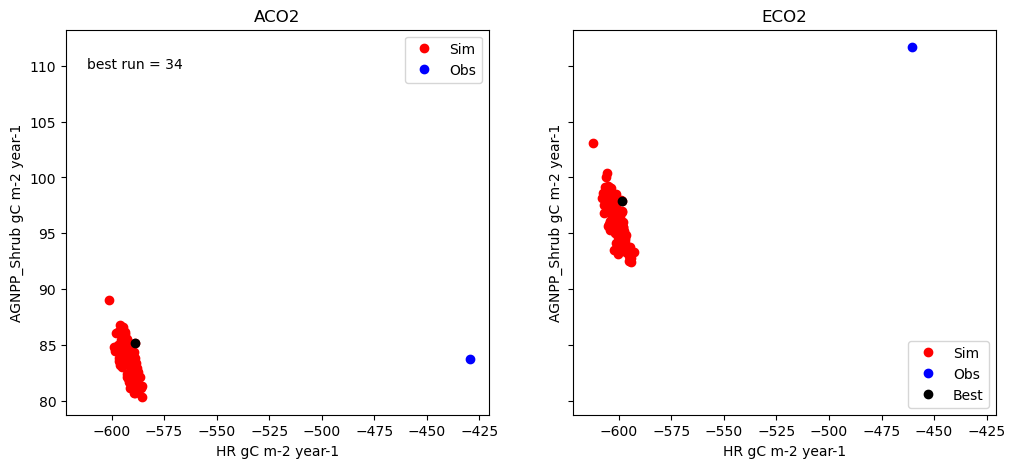

In [13]:
# Shrub's AGNPP and HR

prefix = 'UQ_20240312_test20241025'

ind_y = 8
name_y = 'AGNPP_Shrub'
unit_y = 'gC m-2 year-1'
ind_x = -2
name_x = 'HR'
unit_x = 'gC m-2 year-1'

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][:, ind_y, i, 0]
    mean_y_obs = collection_obs.loc[(name_y,co2), 'mean']
    mean_x = collection_sim[prefix][:, ind_x, i, 0]
    mean_x_obs = collection_obs.loc[(name_x,co2), 'mean']
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_x_obs,  mean_y_obs, 'o', color = 'b', label = 'Obs')
    ax.legend()

    distance[co2] = \
        np.sqrt( np.power((mean_x - mean_x_obs) / mean_x_obs.mean(), 2) \
                + np.power((mean_y - mean_y_obs) / mean_y_obs.mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][best, ind_y, i, 0]
    mean_x = collection_sim[prefix][best, ind_x, i, 0]
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'k', label = 'Best')
    ax.set_xlabel(f'{name_x} {unit_x}')
    ax.set_ylabel(f'{name_y} {unit_y}')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

3081


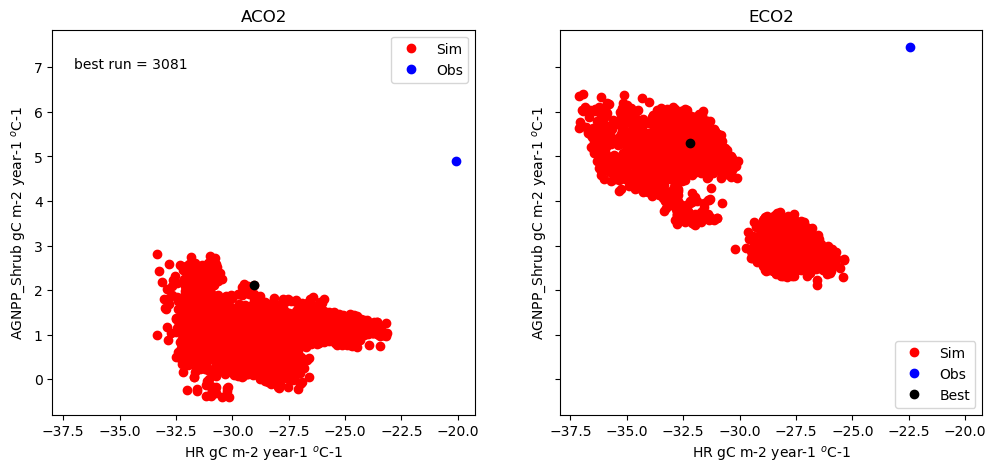

In [ ]:
# Shrub's AGNPP and HR

prefix = 'UQ_20240312_test20241017'

ind_y = 8
name_y = 'AGNPP_Shrub'
unit_y = 'gC m-2 year-1 $^o$C-1'
ind_x = -2
name_x = 'HR'
unit_x = 'gC m-2 year-1 $^o$C-1'

distance = {}
fig, axes = plt.subplots(1, 2, figsize = (12, 5), sharex = True, sharey = True)
for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][:, ind_y, i, 2]
    mean_y_obs = collection_obs.loc[(name_y,co2), 'slope']
    mean_x = collection_sim[prefix][:, ind_x, i, 2]
    mean_x_obs = collection_obs.loc[(name_x,co2), 'slope']
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'r', label = 'Sim')
    ax.plot(mean_x_obs,  mean_y_obs, 'o', color = 'b', label = 'Obs')
    ax.legend()

    distance[co2] = \
        np.sqrt( np.power((mean_x - mean_x_obs) / mean_x_obs.mean(), 2) \
                + np.power((mean_y - mean_y_obs) / mean_y_obs.mean(), 2) )

distance2 = np.sqrt( distance['amb']**2 + distance['elev']**2 )
best = np.argmin(distance2)
print(best)

for i, co2 in enumerate(['amb', 'elev']):
    mean_y = collection_sim[prefix][best, ind_y, i, 2]
    mean_x = collection_sim[prefix][best, ind_x, i, 2]
    #if name_x in ['HR', 'NEE']:
    #    mean_x = - mean_x

    ax = axes.flat[i]
    ax.plot(mean_x,  mean_y, 'o', color = 'k', label = 'Best')
    ax.set_xlabel(f'{name_x} {unit_x}')
    ax.set_ylabel(f'{name_y} {unit_y}')
    if i == 0:
        ax.set_title('ACO2')
    else:
        ax.set_title('ECO2')

    if i == 0:
        ax.text(0.05, 0.9, f'best run = {best}', transform = ax.transAxes)
    else:
        ax.legend(loc = 'lower right')

In [ ]:
prefix = 'UQ_20240312_test20241017'
N = 3125

# Tree to shrub ratios
spruce_npp = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
tamarack_npp = collection_sim[prefix][:, 7, :, 0].mean(axis = 1)
shrub_npp = collection_sim[prefix][:, 8, :, 0].mean(axis = 1)
tree_shrub_ratio =  tamarack_npp / shrub_npp

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, -3, :, 0].mean(axis = 1)

# The sensitivity of AGNPP to temperature
spruce_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)
tamarack_sensitivity = collection_sim[prefix][:, 7, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 8, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, -3, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_mean = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, -2, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, -1, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, -1, :, 2].mean(axis = 1)

def fit_line(x, y):
    filt = ~np.isnan(x) & ~np.isnan(y)
    x = x[filt]
    y = y[filt]

    if sum(filt) == 0:
        return np.nan, np.nan, np.nan, np.nan, np.nan

    res = linregress(x, y)
    xnew = np.linspace(x.min(), x.max(), 3)
    ynew = res.slope * xnew + res.intercept
    r2 = res.rvalue**2  # coefficient of determination
    return xnew, ynew, res.slope, res.intercept, r2

Text(0, 0.5, 'Sensitivity of NEE to warming')

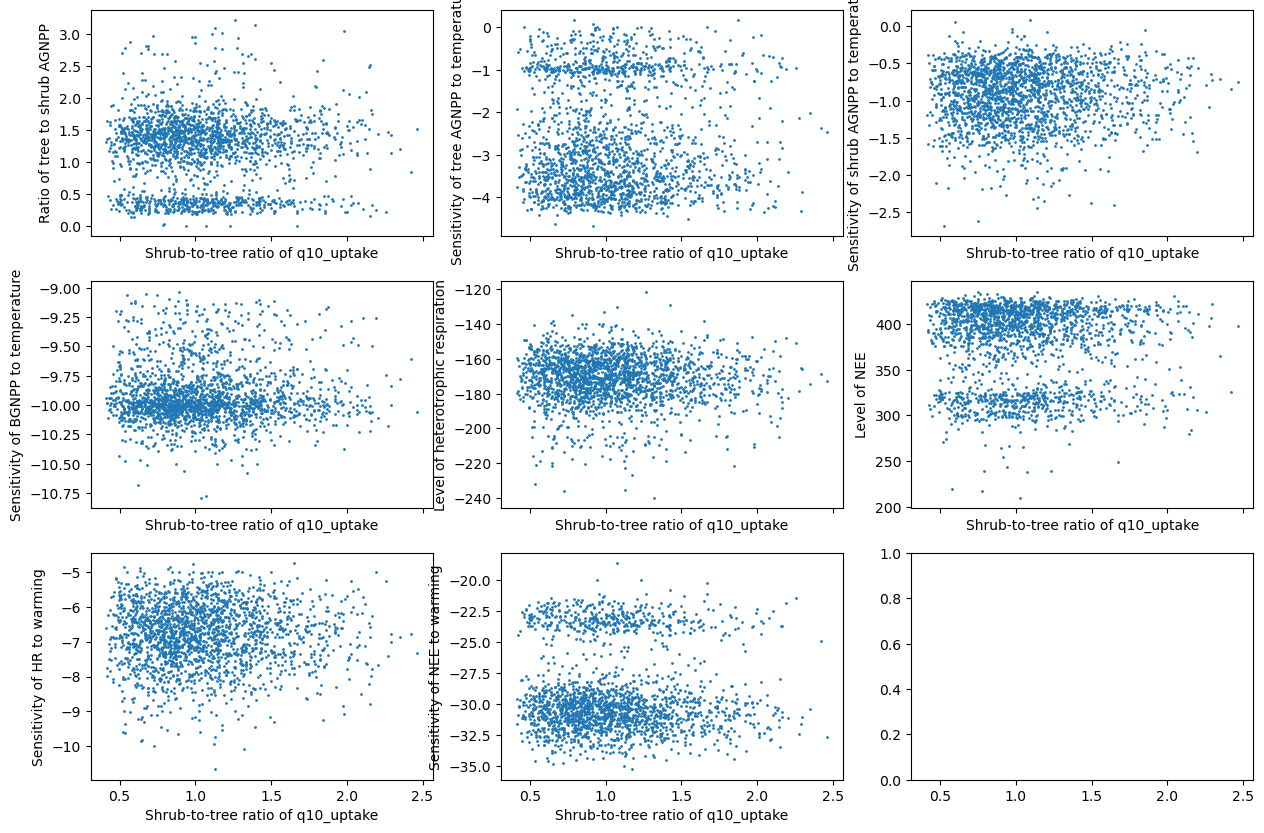

In [ ]:
# without PFT-specific sizing, there is no result what so ever
q10_collect = get_params(prefix, 'q10_uptake', N)
q10_ratio = q10_collect[:,11] / q10_collect[:,2:3].mean(axis = 1)

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)

ax = axes.flat[0]
ax.plot(q10_ratio, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(q10_ratio, tamarack_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(q10_ratio, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(q10_ratio, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

ax = axes.flat[4]
ax.plot(q10_ratio, hr, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of heterotrophic respiration')

ax = axes.flat[5]
ax.plot(q10_ratio, nee, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of NEE')

ax = axes.flat[6]
ax.plot(q10_ratio, hr_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of HR to warming')

ax = axes.flat[7]
ax.plot(q10_ratio, nee_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of NEE to warming')

In [ ]:
km_froot_n = get_params(prefix, 'km_froot_n', N)
km_froot_n = km_froot_n[:, 0]

fungi_cost_n = get_params(prefix, 'fungi_cost_n', N)
fungi_cost_n = fungi_cost_n[:, 0]

vmax_froot_n = get_params(prefix, 'vmax_froot_n', N)
vmax_froot_n = vmax_froot_n[:,11]

vmax_fungi_son = get_params(prefix, 'vmax_fungi_son', N)
vmax_fungi_son = vmax_fungi_son[:,11]

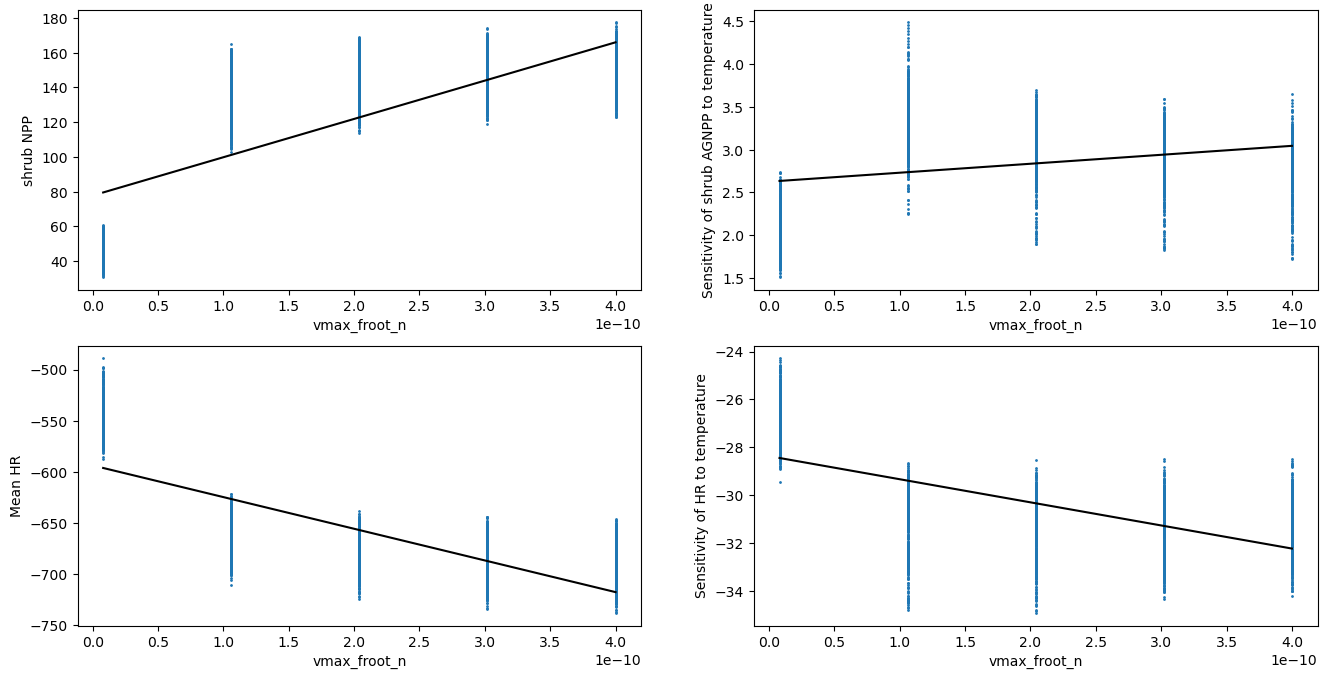

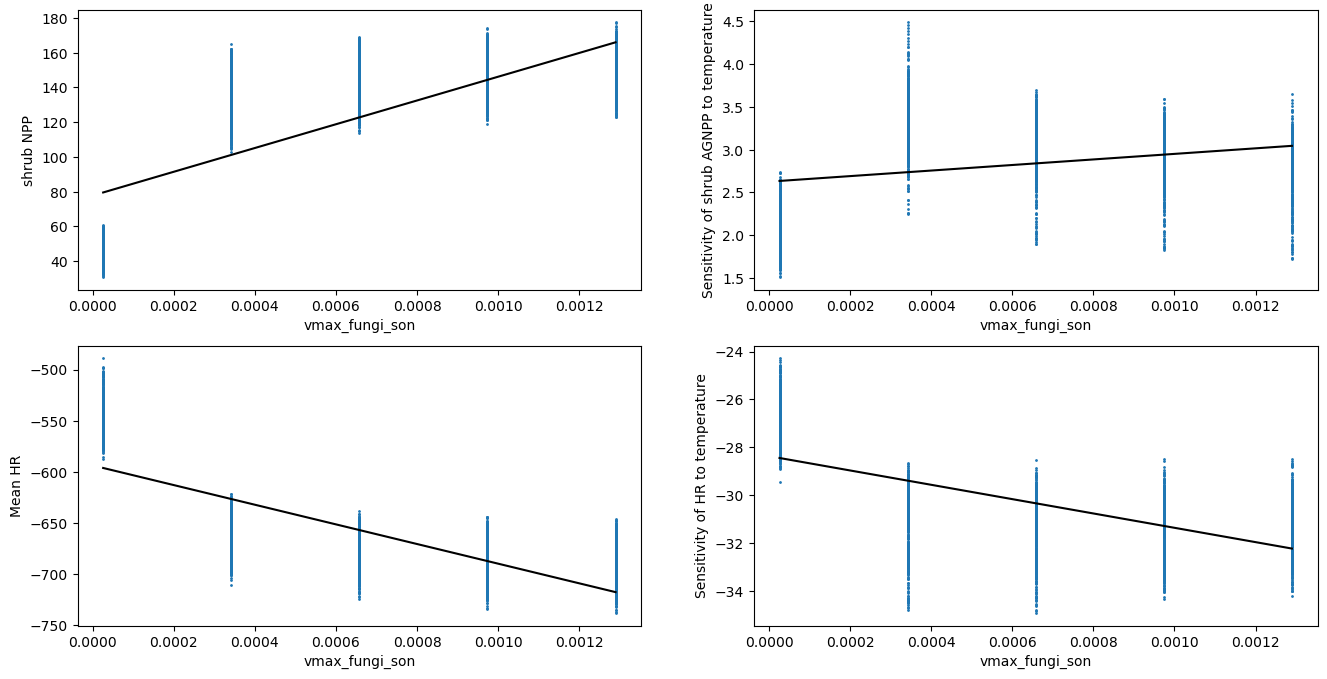

In [ ]:
#for varname, var in zip(
#    ['km_froot_n', 'fungi_cost_n'], 
#    [km_froot_n, fungi_cost_n]
#):
for varname, var in zip(
    ['vmax_froot_n', 'vmax_fungi_son'],
    [vmax_froot_n, vmax_fungi_son]
):
    fig, axes = plt.subplots(2, 2, figsize = (16, 8))

    ax = axes.flat[0]
    ax.plot(var, shrub_npp, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('shrub NPP')
    xnew, ynew, slope, intercept, r2 = fit_line(var, shrub_npp)
    ax.plot(xnew, intercept + xnew * slope, '-k')

    ax = axes.flat[1]
    #response = shrub_sensitivity / shrub_npp
    #rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
    response = shrub_sensitivity
    rname = 'Sensitivity of shrub AGNPP to temperature'
    ax.plot(var, response, 'o', ms = 1)
    ax.set_ylabel(rname)
    xnew, ynew, slope, intercept, r2 = fit_line(var, response)
    ax.plot(xnew, intercept + xnew * slope, '-k')
    ax.set_xlabel(varname)

    ax = axes.flat[2]
    ax.plot(var, hr_mean, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('Mean HR')
    xnew, ynew, slope, intercept, r2 = fit_line(var, hr_mean)
    ax.plot(xnew, intercept + xnew * slope, '-k')

    ax = axes.flat[3]
    ax.plot(var, hr_sensitivity, 'o', ms = 1)
    ax.set_xlabel(varname)
    ax.set_ylabel('Sensitivity of HR to temperature')
    xnew, ynew, slope, intercept, r2 = fit_line(var, hr_sensitivity)
    ax.plot(xnew, intercept + xnew * slope, '-k')

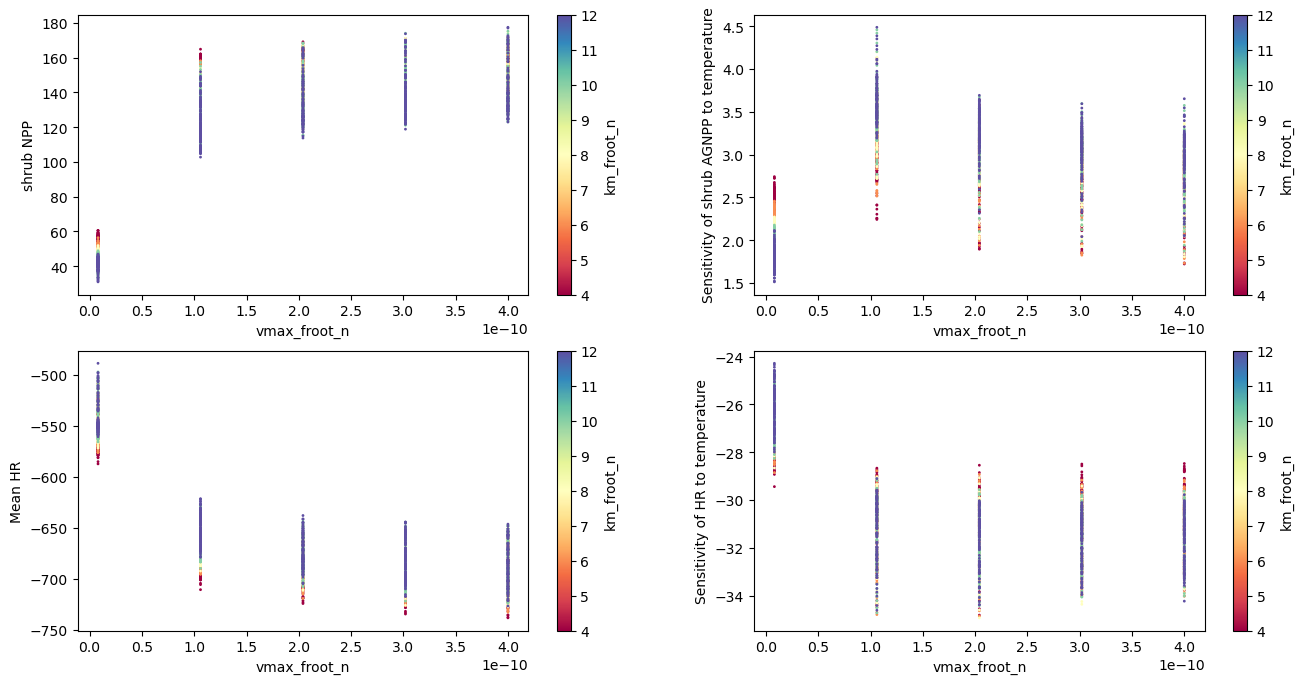

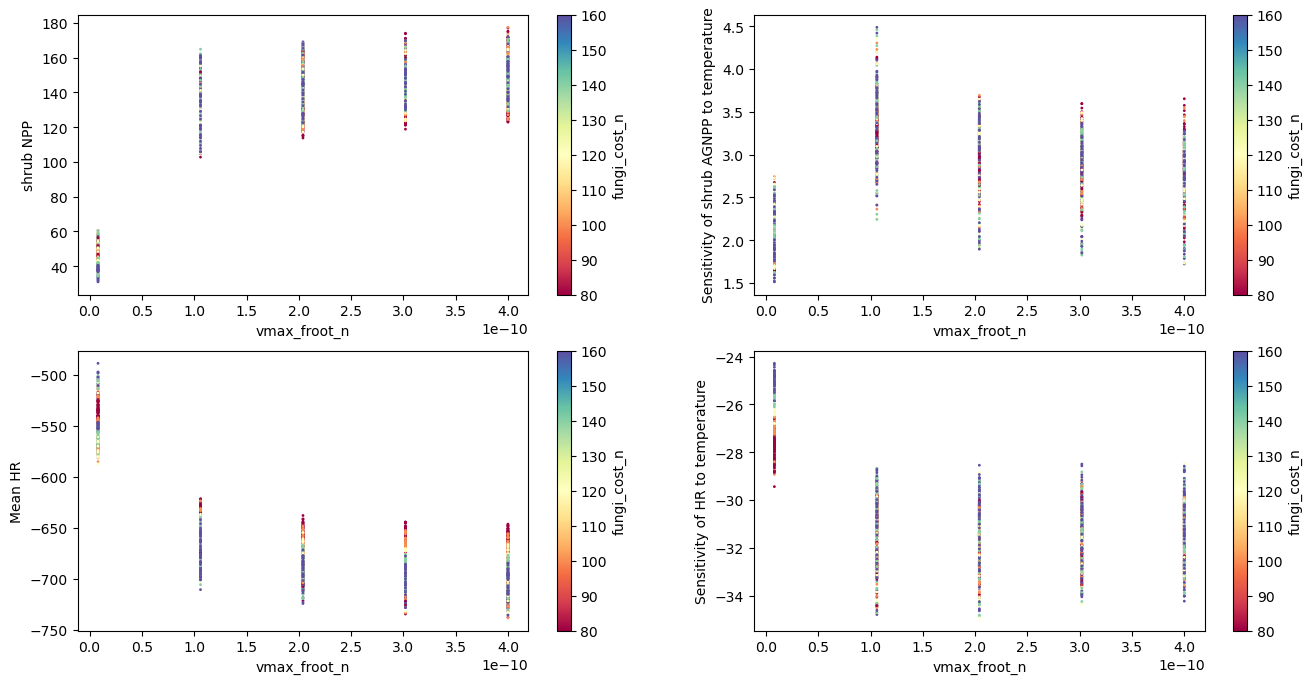

In [ ]:
# Colorized plot
varname = 'vmax_froot_n'
var = vmax_froot_n

for varc_name, varcolor in zip(
     ['km_froot_n', 'fungi_cost_n'], 
    [km_froot_n, fungi_cost_n]
):
    fig, axes = plt.subplots(2, 2, figsize = (16, 8))

    ax = axes.flat[0]
    cf = ax.scatter(var, shrub_npp, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('shrub NPP')
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[1]
    #response = shrub_sensitivity / shrub_npp
    #rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
    response = shrub_sensitivity
    rname = 'Sensitivity of shrub AGNPP to temperature'
    cf = ax.scatter(var, response, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_ylabel(rname)
    ax.set_xlabel(varname)
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[2]
    cf = ax.scatter(var, hr_mean, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('Mean HR')
    plt.colorbar(cf, ax = ax, label = varc_name)

    ax = axes.flat[3]
    cf = ax.scatter(var, hr_sensitivity, s = 1, c = varcolor, cmap = 'Spectral')
    ax.set_xlabel(varname)
    ax.set_ylabel('Sensitivity of HR to temperature')
    plt.colorbar(cf, ax = ax, label = varc_name)

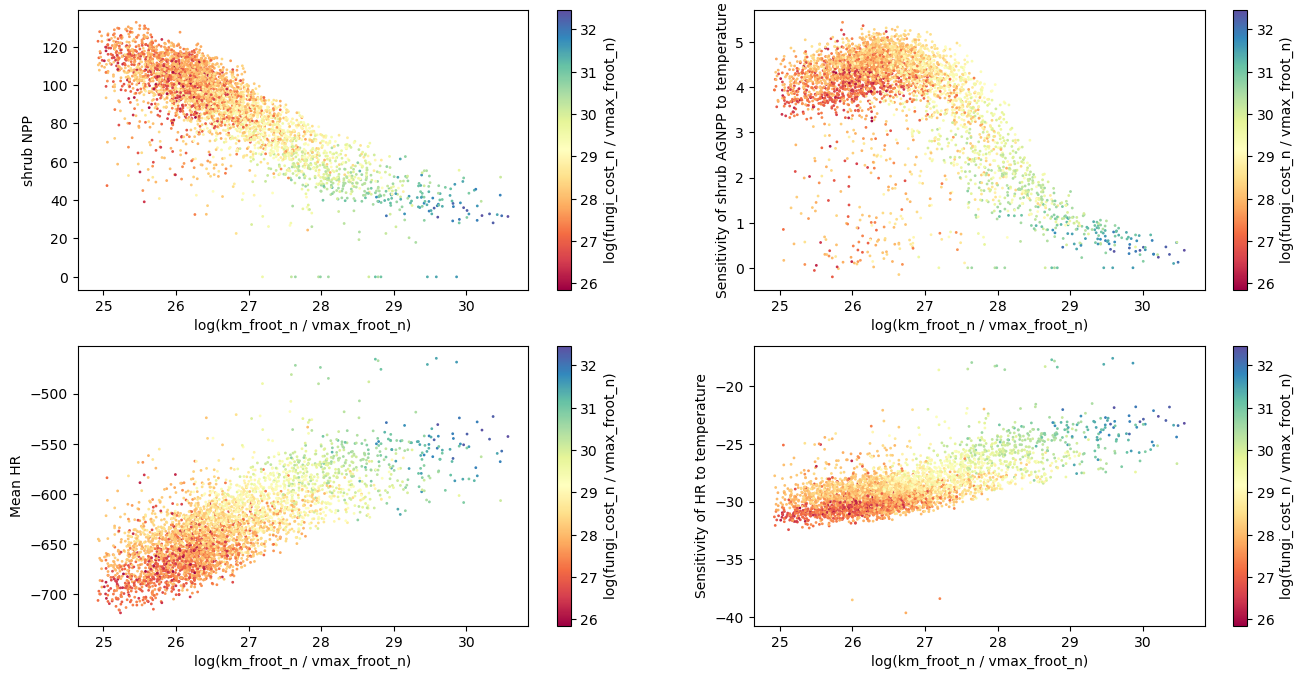

In [ ]:
# Colorized plot of ratios
varname_x = 'log(km_froot_n / vmax_froot_n)'
var_x = np.log(km_froot_n / vmax_froot_n)
varname_y = 'log(fungi_cost_n / vmax_froot_n)'
var_y = np.log(fungi_cost_n / vmax_froot_n)

fig, axes = plt.subplots(2, 2, figsize = (16, 8))

ax = axes.flat[0]
cf = ax.scatter(var_x, shrub_npp, s = 1, c = var_y, cmap = 'Spectral')
ax.set_xlabel(varname_x)
ax.set_ylabel('shrub NPP')
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[1]
#response = shrub_sensitivity / shrub_npp
#rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
response = shrub_sensitivity
rname = 'Sensitivity of shrub AGNPP to temperature'
cf = ax.scatter(var_x, response, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel(rname)
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[2]
cf = ax.scatter(var_x, hr_mean, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Mean HR')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[3]
cf = ax.scatter(var_x, hr_sensitivity, s = 1, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Sensitivity of HR to temperature')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

In [ ]:
# What does the joint distribution of vmax_froot_n & vmax_fungi_son look like?
prefix = 'UQ_20240312_test20241012'
N = 100

# Tree to shrub ratios
spruce_npp = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
tamarack_npp = collection_sim[prefix][:, 7, :, 0].mean(axis = 1)
shrub_npp = collection_sim[prefix][:, 8, :, 0].mean(axis = 1)
tree_shrub_ratio =  tamarack_npp / shrub_npp

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, -3, :, 0].mean(axis = 1)

# The sensitivity of AGNPP to temperature
spruce_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)
tamarack_sensitivity = collection_sim[prefix][:, 7, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 8, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, -3, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_mean = collection_sim[prefix][:, -2, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, -2, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, -1, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, -1, :, 2].mean(axis = 1)

vmax_froot_n = get_params(prefix, 'vmax_froot_n', N)
vmax_froot_n = vmax_froot_n[:,11]

vmax_fungi_son = get_params(prefix, 'vmax_fungi_son', N)
vmax_fungi_son = vmax_fungi_son[:,11]

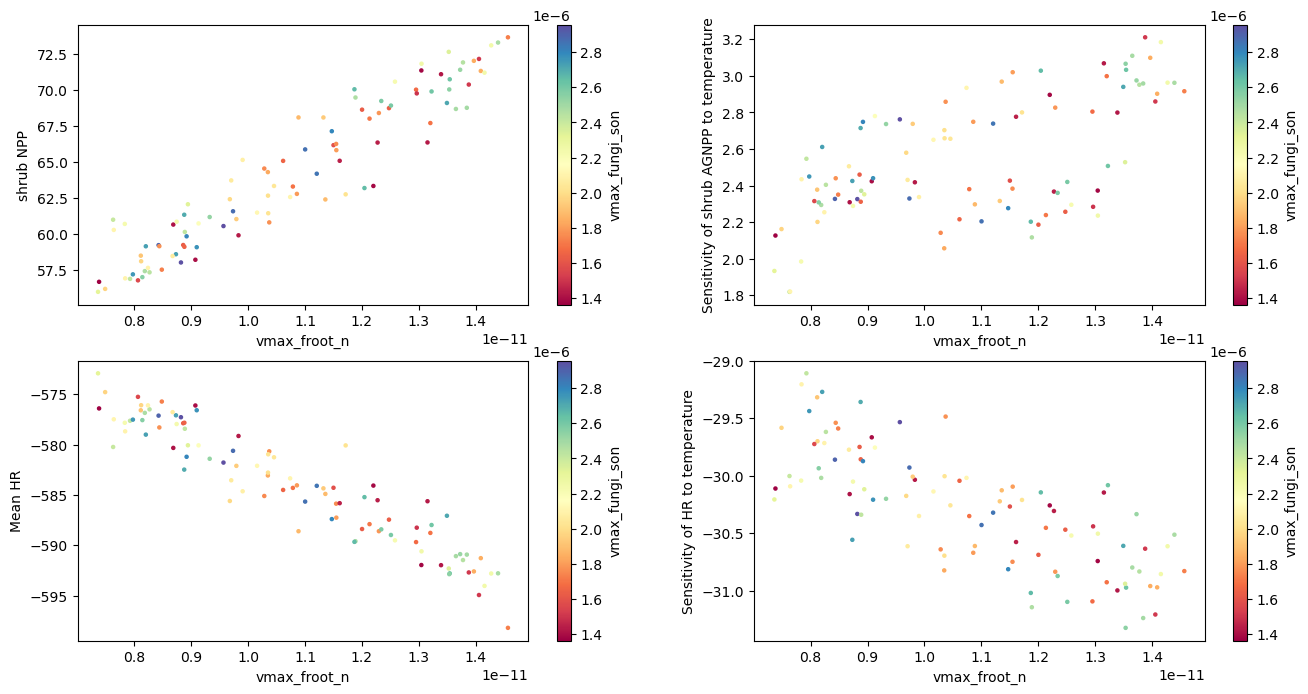

In [ ]:
# Colorized plot of ratios
varname_x = 'vmax_froot_n'
var_x = vmax_froot_n
varname_y = 'vmax_fungi_son'
var_y = vmax_fungi_son

fig, axes = plt.subplots(2, 2, figsize = (16, 8))

ax = axes.flat[0]
cf = ax.scatter(var_x, shrub_npp, s = 5, c = var_y, cmap = 'Spectral')
ax.set_xlabel(varname_x)
ax.set_ylabel('shrub NPP')
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[1]
#response = shrub_sensitivity / shrub_npp
#rname = 'Sensitivity of shrub AGNPP to temperature \n / Shrub AGNPP ($^o$C$^{-1}$)'
response = shrub_sensitivity
rname = 'Sensitivity of shrub AGNPP to temperature'
cf = ax.scatter(var_x, response, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel(rname)
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[2]
cf = ax.scatter(var_x, hr_mean, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Mean HR')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

ax = axes.flat[3]
cf = ax.scatter(var_x, hr_sensitivity, s = 5, c = var_y, cmap = 'Spectral')
ax.set_ylabel('Sensitivity of HR to temperature')
ax.set_xlabel(varname_x)
plt.colorbar(cf, ax = ax, label = varname_y)

In [ ]:
# froot_leaf larger for trees means lower tree AGNPP compared to shrub
# especially for the evergreen. whereas froot_leaf larger for shrub has
# the opposite effect. Larger belowground allocation means lower 
# aboveground advantage, makes sense

# Evergreen is dominating the BG-to-AG ratio in the eventual result

alloccollect = get_params(prefix, 'froot_leaf', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], tree_shrub_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of tree AGNPP to shrub AGNPP')

    # observed level
    obs = collection_obs.loc['ANPPtree', 'mean'].mean() / \
        collection_obs.loc['ANPPshrub', 'mean'].mean()
    ax.axhline(obs, color = 'r', lw = 2)

# when shrub's ratio < 0.25, what does the tree AGNPP & shrub AGNPP compare to obs?


fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], bg_ag_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of BGNPP to AGNPP')

    # observed level
    obs = collection_obs.loc['BGNPP', 'mean'].mean() / \
        (collection_obs.loc['ANPPtree', 'mean'].mean() + \
        collection_obs.loc['ANPPshrub', 'mean'].mean()) 
    ax.axhline(obs, color = 'r', lw = 2)

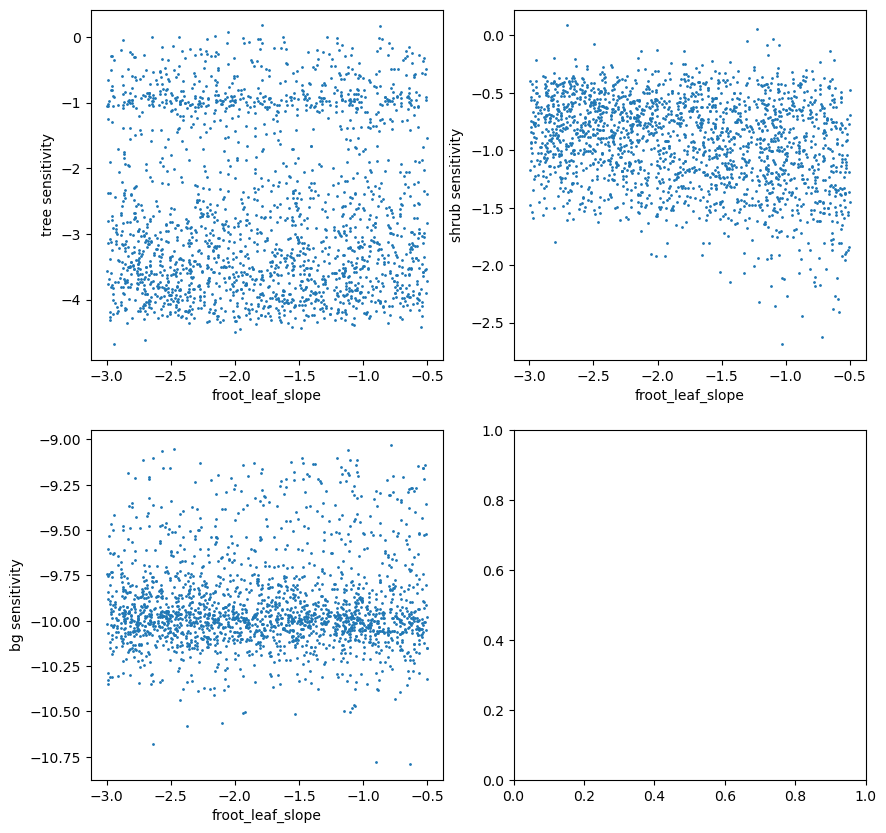

In [ ]:
#alloccollect = get_params(prefix, 'froot_leaf_slope', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, (name,sens) in enumerate(zip(["tree","shrub","bg"],
                                    [tamarack_sensitivity, shrub_sensitivity,bgnpp_sensitivity])):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, 11], sens, 'o', ms = 1)
    ax.set_xlabel('froot_leaf_slope')
    ax.set_ylabel(f'{name} sensitivity')

## Find the parameter ranges for desired sensitivities and mean

In [ ]:
selected_runs = np.where(
    (shrub_sensitivity >= 0) & (tree_sensitivity < 0.0) & (bgnpp_sensitivity > -10)
)[0] + 1
print(selected_runs)

[264]


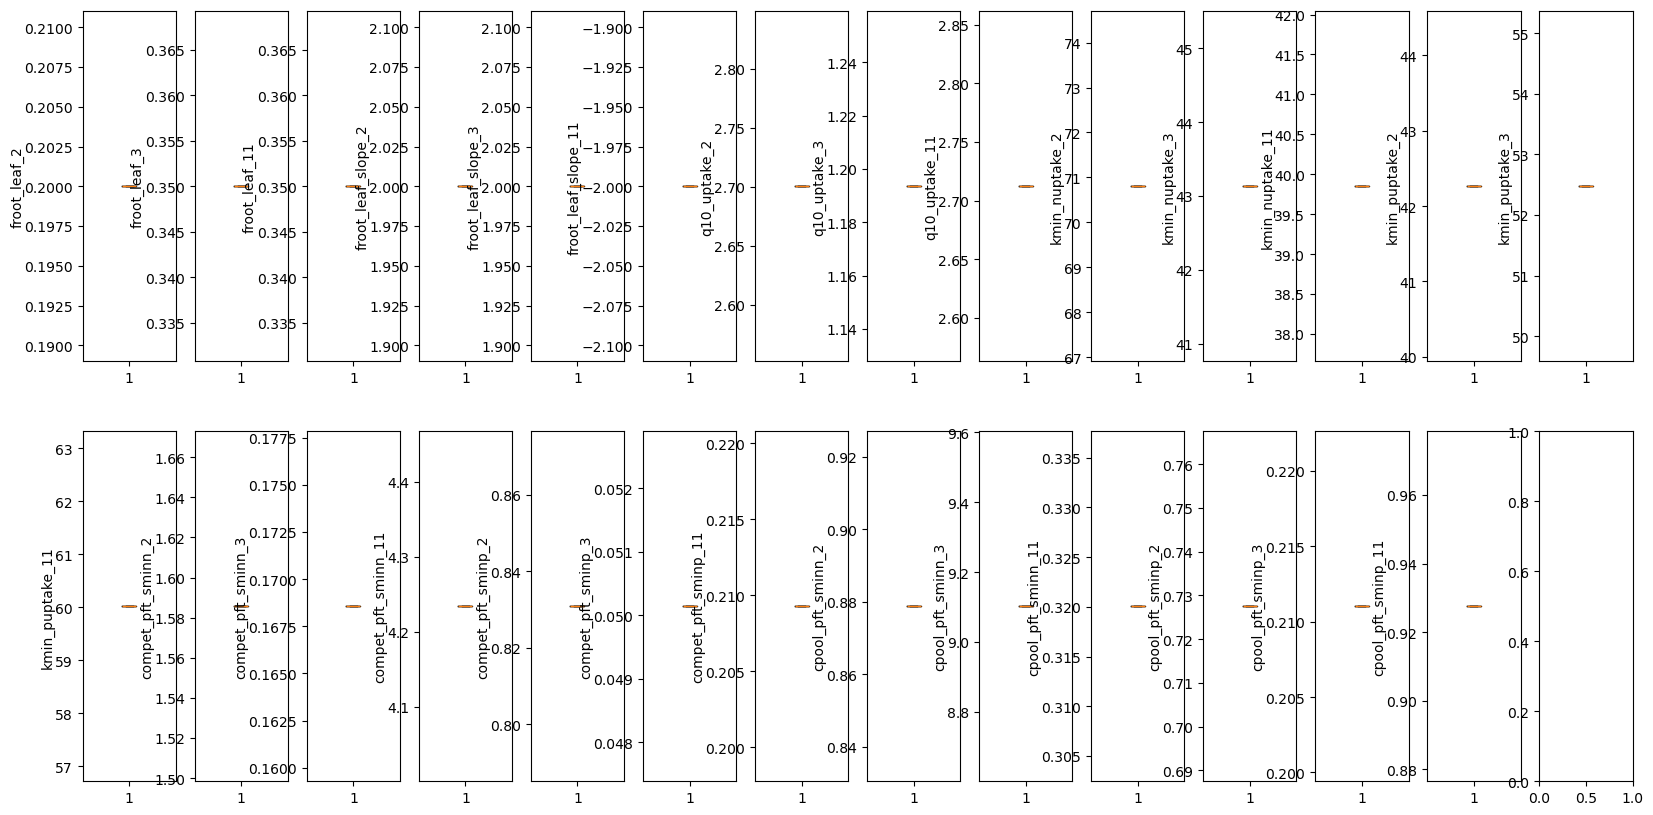

In [ ]:
params_collect = {}
for parname in ['froot_leaf', 'froot_leaf_slope', 'q10_uptake', 'kmin_nuptake', 'kmin_puptake', 
                'compet_pft_sminn', 'compet_pft_sminp', 'compet_pft_sminp', 
                'cpool_pft_sminn', 'cpool_pft_sminp']: # , 'alpha_fpg', 'alpha_fpg_p'
    parvals = get_params(prefix, parname, 2000, selected_runs)
    if parvals.shape[1] == 1:
        params_collect[parname] = parvals
    else:
        for pft in [2, 3, 11]:
            params_collect[f'{parname}_{pft}'] = parvals[:, pft]

params_list = list(params_collect.keys())
fig, axes = plt.subplots(2, int(np.ceil(len(params_collect) / 2)), figsize = (20, 10))
fig.subplots_adjust(wspace = 0.2)
for i in range(len(params_list)):
    ax = axes.flat[i]
    ax.boxplot(params_collect[params_list[i]])
    ax.set_ylabel(params_list[i], labelpad=0)